In [84]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shapely

import plotting
from transformers import TrackCellTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [85]:
df_tracks = gpd.read_parquet("../data/cleaned/track_info.parquet")
df_routes = pd.read_csv("../data/raw/routes.csv")
df_routes['Template Track'] = pd.to_datetime(df_routes['Template Track'], utc=True, errors='coerce')

create some sort of interactive tool to go through each template track and identify unknown segments and add them to a master list. Have the master list plotted for reference.

In [86]:
df_tracks

,track_file,track_file_datetime,track_file_date,day_of_week,start_datetime,end_datetime,num_pauses,total_duration,active_duration,total_distance (mi),average_pace (min/mi),total_ascent (m),total_descent (m),year,season,region,start_point,end_point,track_line
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00-05:00,2019-06-10,Monday,2019-06-10 11:57:42+00:00,2019-06-10 12:46:10+00:00,0,0 days 00:48:28,0 days 00:48:28,3.060933,8.542777,39.011887,-38.079392,Freshman,Summer Training,Thompson/Davis,POINT (-88.32154 41.91101),POINT (-88.32166 41.9109),"MULTILINESTRING ((-88.32154 41.91101, -88.3215..."
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00-05:00,2019-06-11,Tuesday,2019-06-11 11:59:03+00:00,2019-06-11 12:32:23+00:00,5,0 days 00:33:20,0 days 00:33:10,3.154848,8.785222,60.890730,-61.285231,Freshman,Summer Training,LeRoy/Great West,POINT (-88.34764 41.928),POINT (-88.34792 41.92783),"MULTILINESTRING ((-88.34764 41.928, -88.34764 ..."
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00-05:00,2019-06-12,Wednesday,2019-06-12 11:53:36+00:00,2019-06-12 12:35:13+00:00,5,0 days 00:41:43,0 days 00:30:46,2.521019,8.567542,68.381334,-63.546495,Freshman,Summer Training,Thompson/Davis,POINT (-88.32153 41.91251),POINT (-88.32172 41.911),"MULTILINESTRING ((-88.32153 41.91251, -88.3215..."
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-17 07:22:00-05:00,2019-06-17,Monday,2019-06-17 11:52:32+00:00,2019-06-17 12:22:32+00:00,0,0 days 00:30:00,0 days 00:30:00,2.981428,9.099587,43.081880,-42.863923,Freshman,Summer Training,Thompson/Davis,POINT (-88.32145 41.911),POINT (-88.32154 41.91096),"MULTILINESTRING ((-88.32145 41.911, -88.32143 ..."
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-18 07:19:00-05:00,2019-06-18,Tuesday,2019-06-18 11:53:58+00:00,2019-06-18 12:19:21+00:00,3,0 days 00:25:23,0 days 00:25:03,2.343798,9.394596,49.200207,-46.531003,Freshman,Summer Training,LeRoy/Great West,POINT (-88.35416 41.92575),POINT (-88.34797 41.92783),"MULTILINESTRING ((-88.35416 41.92575, -88.3541..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,/Users/ryansponzilli/Developer/Python Projects...,2023-05-03 15:31:00-05:00,2023-05-03,Wednesday,2023-05-03 19:57:04+00:00,2023-05-03 20:31:52+00:00,3,0 days 00:34:48,0 days 00:29:12,3.726018,7.549088,30.617863,-30.919904,Senior,Track Season,School/Fox Chase,POINT (-88.2791 41.92803),POINT (-88.27995 41.92839),"MULTILINESTRING ((-88.2791 41.92803, -88.27908..."
799,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:10:00-05:00,2023-05-04,Thursday,2023-05-04 19:54:31+00:00,2023-05-04 20:42:07+00:00,8,0 days 00:29:13,0 days 00:20:16,3.002786,6.266090,13.999019,-13.247170,Senior,Track Season,School/Fox Chase,POINT (-88.27989 41.92867),POINT (-88.27658 41.92851),"MULTILINESTRING ((-88.27989 41.92867, -88.2798..."
800,/Users/ryansponzilli/Developer/Python Projects...,2023-05-05 15:11:00-05:00,2023-05-05,Friday,2023-05-05 19:44:31+00:00,2023-05-05 20:11:23+00:00,4,0 days 00:26:52,0 days 00:25:05,3.484011,7.014577,21.619114,-22.143583,Senior,Track Season,School/Fox Chase,POINT (-88.27988 41.92846),POINT (-88.27952 41.9282),"MULTILINESTRING ((-88.27988 41.92846, -88.2798..."
801,/Users/ryansponzilli/Developer/Python Projects...,2023-05-06 11:15:00-05:00,2023-05-06,Saturday,2023-05-06 15:58:49+00:00,2023-05-06 16:15:16+00:00,5,0 days 00:16:29,0 days 00:15:05,1.949441,7.702272,19.363362,-19.434180,Senior,Track Season,Other,POINT (-88.32204 41.95011),POINT (-88.32167 41.95012),"MULTILINESTRING ((-88.32204 41.95011, -88.3220..."


In [87]:
segment_routes = df_routes.loc[(df_routes['Region'] == "School/Fox Chase") & (df_routes['Route Type'] == "Normal")].sort_values("N", ascending=False)
segment_routes

,Cluster ID,N,Region,Route Type,Route Name,Template Track,Notes
34,34,62,School/Fox Chase,Normal,Persimmon Loop,2022-08-12 20:38:00+00:00,NaN
33,33,48,School/Fox Chase,Normal,Dog Leg Loop,2022-08-26 20:36:00+00:00,NaN
14,14,23,School/Fox Chase,Normal,Buddy's Loop,2021-07-22 12:29:00+00:00,NaN
39,38,16,School/Fox Chase,Normal,25 & Back,2020-01-24 21:20:00+00:00,NaN
12,12,14,School/Fox Chase,Normal,K's Loop,2022-09-07 20:29:00+00:00,NaN
18,18,14,School/Fox Chase,Normal,Cornerstone OAB,NaT,NaN
16,16,11,School/Fox Chase,Normal,Cornerstone Loop,2022-12-26 14:50:00+00:00,NaN
27,27,11,School/Fox Chase,Normal,Duke's Loop,2020-01-04 15:07:00+00:00,NaN
36,36,9,School/Fox Chase,Normal,Lake Loop,2021-08-27 20:25:00+00:00,NaN
47,46,8,School/Fox Chase,Normal,Around the Track,2023-04-18 21:22:00+00:00,NaN


In [88]:
def trim_segment(route_name, start=None, end=None):
    fig, ax = plt.subplots(figsize=(6,6))
    persimmon_route = df_tracks.loc[df_tracks['track_file_datetime'] == segment_routes.loc[segment_routes['Route Name'] == route_name, "Template Track"].iloc[0]]
    gdf = gpd.GeoDataFrame(geometry=[shapely.Point(point) for geom in persimmon_route['track_line'].iloc[0].geoms for point in geom.coords], crs="EPSG:4326")

    if start == None:
        start=0
    if end == None:
        end = len(gdf)

    plotting.plot_map(gdf[start:end], ax=ax)

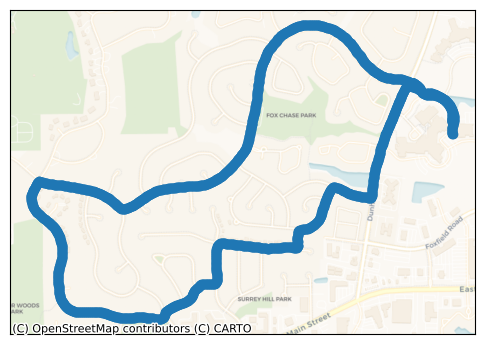

In [89]:
trim_segment("Persimmon Loop")

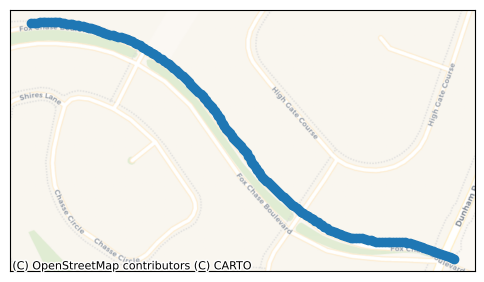

In [90]:
trim_segment("Persimmon Loop", start=120, end=300)

In [91]:
import geopandas as gpd
from ipyleaflet import Map, DrawControl, CircleMarker
from ipywidgets import Layout

# convert to lat/lon for Leaflet
route_name = "Persimmon Loop"
route = df_tracks.loc[df_tracks['track_file_datetime'] == segment_routes.loc[segment_routes['Route Name'] == route_name, "Template Track"].iloc[0]]
gdf = gpd.GeoDataFrame(geometry=[shapely.Point(point) for geom in route['track_line'].iloc[0].geoms for point in geom.coords], crs="EPSG:4326")
gdf_ll = gdf.to_crs(4326)

center = [
    gdf_ll.geometry.y.mean(),
    gdf_ll.geometry.x.mean()
]


m = Map(center=center, zoom=15, layout=Layout(width="1000px", height="600px"))

for point in gdf_ll.geometry:
    marker = CircleMarker(
        location=(point.y, point.x),
        radius=2,
        color="blue",
        fill_color="blue",
        fill_opacity=1.0,
        weight=1,
    )
    m.add(marker)

draw = DrawControl()

draw.polygon = {
    "shapeOptions": {
        "color": "#ff0000"
    }
}

draw.rectangle = {}
draw.circle = {}
draw.circlemarker = {}
draw.polyline = {}
draw.marker = {}

from shapely.geometry import shape

selected = None

def handle_draw(target, action, geo_json):
    global selected

    polygon = shape(geo_json["geometry"])

    selected = gdf_ll[gdf_ll.geometry.within(polygon)]

draw.on_draw(handle_draw)

m.add(draw)

Map(center=[np.float64(41.926276504682626), np.float64(-88.29223772008326)], controls=(ZoomControl(options=['p…

In [92]:
selected